In [1]:
from pathlib import Path
import pandas as pd

In [72]:
bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth_r = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
# pars_estimates_r = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-responses_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars_ground_truth_l = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCl_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth_r, pars_ground_truth_l][:1], keys=['NPCr', 'NPCl'][:1], names=['roi'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
                                (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes'), 
                                (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
                                (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio')
                                ] )

pars['model'] = pars.index.get_level_values('model_label').map(modelz)
pars = pars[~pars['model'].isnull()]
pars = pars.droplevel('model_label', axis=0).set_index('model', append=True)
cvr2 = pars[('cvr2', 'nan')].unstack('model')
cvr2 = cvr2[(cvr2 > 0.0).any(axis=1)]
cvr2 = cvr2.stack().to_frame('cvr2')

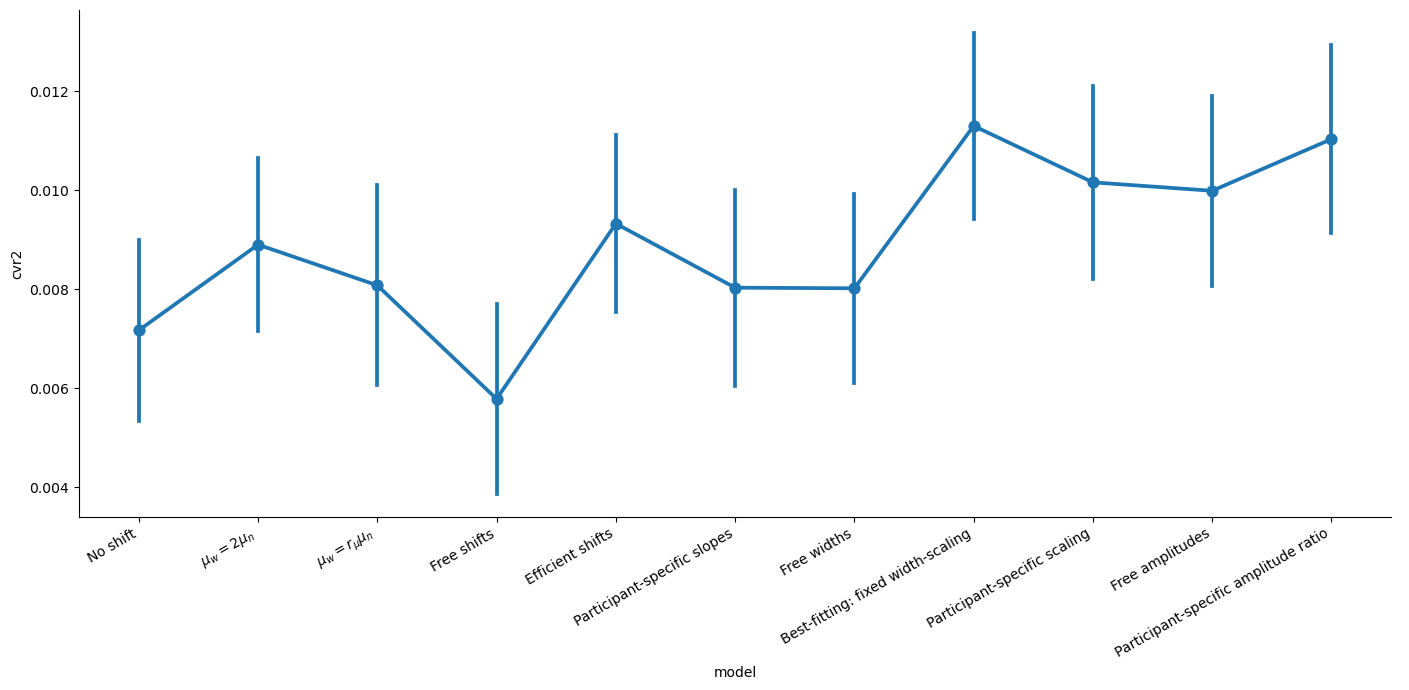

In [79]:


import seaborn as sns
sns.catplot(data=cvr2.groupby(['subject', 'model']).mean().reset_index(), x='model', y='cvr2', kind='point', errorbar='se',
            order=modelz.values(), aspect=2.0, height=7)

# Turn xticks 90 degrees
import matplotlib.pyplot as plt
plt.xticks(rotation=30, ha='right')

plt.tight_layout()

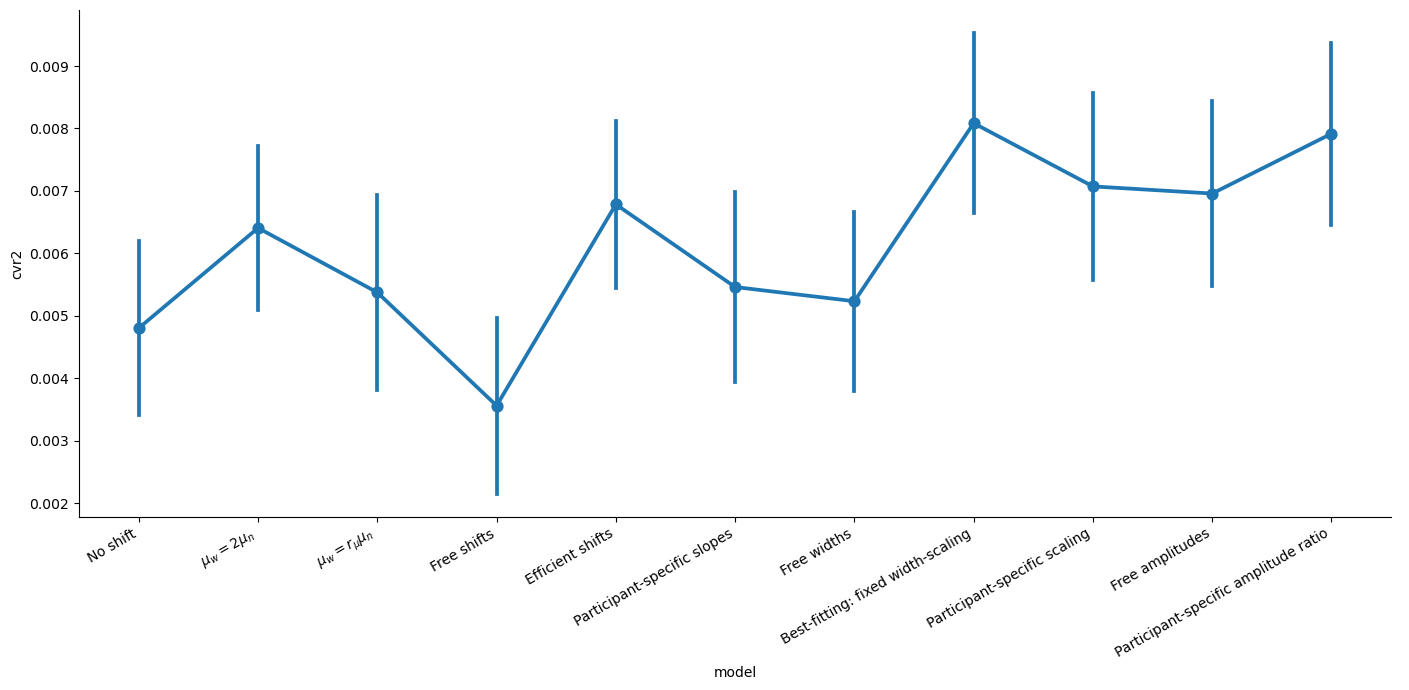

In [77]:


import seaborn as sns
sns.catplot(data=cvr2.groupby(['subject', 'model']).quantile(.5).reset_index(), x='model', y='cvr2', kind='point', errorbar='se',
            order=modelz.values(), aspect=2.0, height=7)

# Turn xticks 90 degrees
import matplotlib.pyplot as plt
plt.xticks(rotation=30, ha='right')

plt.tight_layout()